### Modelo para detección de outliers y cambio de patrón con AR

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
import changefinder 

import pickle

In [55]:
df = pd.read_csv('../df_procesados/df_planta_2.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

#### Función que detecta outliers y cambios según paper: "A Unifying Framework for Detecting Outliers and Change Points from Time Series"

In [56]:
def AR_outlier(
    df,
    col: str,
    lag_ar: int = 2, # AR(2)
    alpha: float = 0.01, 
    quantile: float = 0.9995,

    factor_olvido: float = 0.01,   # factor de olvido (más pequeño = olvida más rápido)
    lag_cambio: int = 1,           # AR cambio 
    suavizado: int = 5,         
    change_quantile: float = 0.999
):
    df = df.copy()

    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time").reset_index(drop=True)

    df = df.dropna(subset=[col])

    x = df[col].astype(float).values
    n = len(x)

    ar = AutoReg(x, lags=lag_ar, old_names=False)
    mod = ar.fit()

    pred = mod.predict(start=lag_ar, end=n-1, dynamic=False)  # ndarray
    residuos = np.full(n, np.nan, dtype=float)
    residuos[lag_ar:] = x[lag_ar:] - pred

    serie_residuos = pd.Series(residuos)
    var_inicial = np.nanvar(serie_residuos.values)
    if not np.isfinite(var_inicial) or var_inicial <= 0:
        var_inicial = 1.0

    s2 = []
    s2_curr = var_inicial
    for r in serie_residuos.values:
        if np.isfinite(r):
            s2_curr = (1 - alpha) * s2_curr + alpha * (r**2)
        s2.append(max(s2_curr, 1e-8))
    s2 = np.array(s2, dtype=float)

    outlier_score = 0.5 * (np.log(2 * np.pi * s2) + (residuos**2) / s2)

    valid_out = np.isfinite(outlier_score)
    thr_out = np.quantile(outlier_score[valid_out], quantile) if valid_out.any() else np.inf
    is_out = outlier_score >= thr_out


    cf = changefinder.ChangeFinder(r=factor_olvido, order=lag_cambio, smooth=suavizado)
    score_cambio = np.array([cf.update(float(v)) for v in x], dtype=float)

    valid_ch = np.isfinite(score_cambio)
    thr_ch = np.quantile(score_cambio[valid_ch], change_quantile) if valid_ch.any() else np.inf
    is_ch = score_cambio >= thr_ch


    labels = np.full(n, "normal", dtype=object)
    labels[is_out] = "outlier"
    labels[is_ch]  = "change"   

    df["outlier_score"] = outlier_score
    df["change_score"] = score_cambio
    df["label"] = labels

    return df

In [40]:
# 定义一个函数来训练和保存AR模型
def train_and_save_ar_model(df, col, lag_ar=2, model_path='ar_model.pkl'):
    """
    训练AR模型并保存到指定路径
    """
    df = df.copy()
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values('date_time').reset_index(drop=True)
    df = df.dropna(subset=[col])
    
    x = df[col].astype(float).values
    
    # 训练AR模型
    ar = AutoReg(x, lags=lag_ar, old_names=False)
    mod = ar.fit()
    
    # 保存模型
    with open(model_path, 'wb') as f:
        pickle.dump(mod, f)
    
    print(f'模型已保存到: {model_path}')
    print(f'模型摘要:')
    print(mod.summary())
    
    return mod

In [57]:
df.columns

Index(['date_time', 'Flujo Cámara de contacto 1',
       'Flujo Salida de Lodo Sedimentador Secundario 3',
       'Flujo Aire Reactor 2', 'Nivel Pozo WAS', 'OD Reactor 2',
       'Flujo Afluente PTAR', 'Flujo Alimentación Digestor 1',
       'Flujo Alimentación Digestor 2', 'Flujo Alimentación Digestor 3',
       'Flujo Aire Reactor 1', 'Flujo Aire Reactor 3', 'OD Reactor 1',
       'Flujo Cámara de contacto 2'],
      dtype='object')

In [42]:
# 执行模型训练与保存
ar_model = train_and_save_ar_model(df_test, col, lag_ar=2, model_path='ar_model.pkl')

模型已保存到: ar_model.pkl
模型摘要:
                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:               301633
Model:                     AutoReg(2)   Log Likelihood             -909174.079
Method:               Conditional MLE   S.D. of innovations              4.930
Date:                Sun, 26 Oct 2025   AIC                        1818356.157
Time:                        19:48:37   BIC                        1818398.625
Sample:                             2   HQIC                       1818368.438
                               301633                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9358      0.012    163.285      0.000       1.913       1.959
y.L1           0.8563      0.002    479.159      0.000       0.853       0.860
y.L2          -0.1913    

In [58]:
col = df.columns[9]
col

'Flujo Alimentación Digestor 3'

In [59]:
df_test = df[["date_time", col]]

if "pH" in col:
    df_test = df_test[df_test[col] <= 14]

In [45]:
df_etiquetado = AR_outlier(df_test, col)

##### Veamos graficamente los outliers y cambios detectados

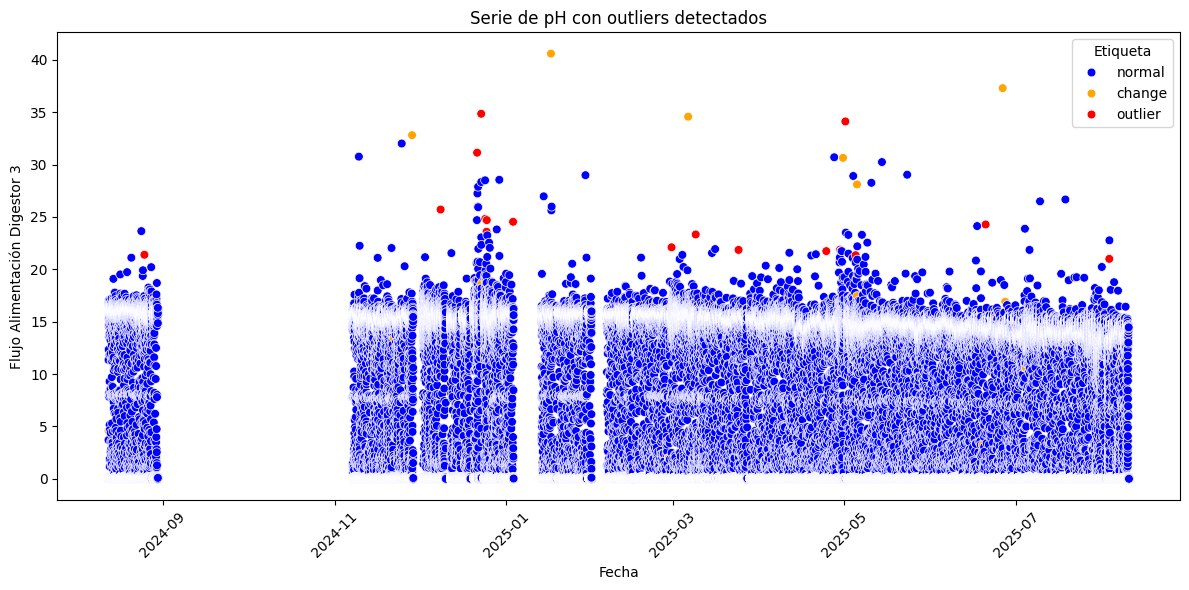

In [46]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_etiquetado,
    x="date_time",
    y= col,
    hue="label",
    palette={"normal":"blue", "outlier":"red", "change":"orange"},
    s=40
)
plt.title("Serie de pH con outliers detectados")
plt.xlabel("Fecha")
plt.ylabel(f"{col}")
plt.legend(title="Etiqueta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
df_etiquetado.describe()

,date_time,Flujo Alimentación Digestor 3,outlier_score,change_score
count,301633,301633.000000,301631.000000,301633.000000
mean,2025-03-14 03:01:20.377677312,5.779215,2.988928,2.700090
min,2024-08-12 17:07:00,0.000000,1.746650,-1.624510
25%,2024-12-31 17:31:00,0.012200,2.558470,1.608900
50%,2025-03-20 07:07:00,0.073200,2.621929,2.560137
75%,2025-05-31 22:26:00,14.701000,2.744776,3.560354
max,2025-08-09 23:58:00,40.600000,17.960794,83.683611
std,NaN,7.224406,1.007112,1.940525


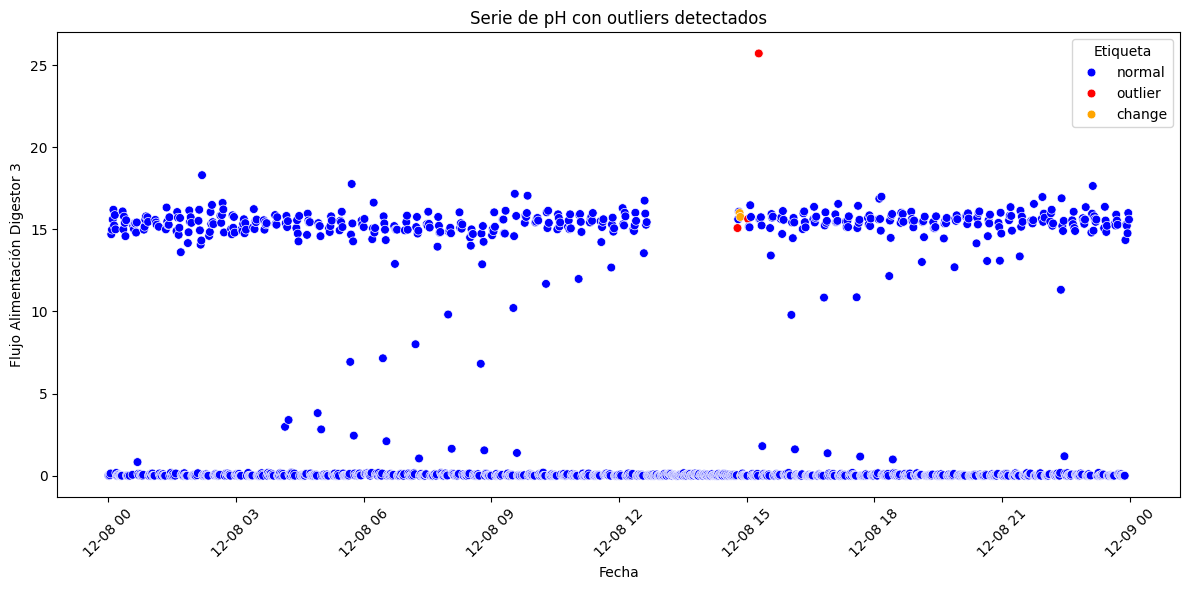

In [48]:
num_outlier = 8

outliers = df_etiquetado.index[df_etiquetado["label"] == "outlier"]

id_outlier = outliers[num_outlier]
data_outlier = df_etiquetado.loc[id_outlier, "date_time"]

dia_mask = df_etiquetado["date_time"].dt.date == data_outlier.date()
df_dia = df_etiquetado[dia_mask]

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_dia,
    x="date_time",
    y= col,
    hue="label",
    palette={"normal":"blue", "outlier":"red", "change":"orange"},
    s=40
)
plt.title("Serie de pH con outliers detectados")
plt.xlabel("Fecha")
plt.ylabel(f"{col}")
plt.legend(title="Etiqueta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 模型验证：使用训练/测试分割评估准确性

In [60]:
# 1. 数据分割：80% 训练 + 20% 测试
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 分割点
split_idx = int(len(df_test) * 0.8)

df_train = df_test.iloc[:split_idx].copy()
df_val = df_test.iloc[split_idx:].copy()

print(f'训练集大小：{len(df_train)}')
print(f'验证集大小：{len(df_val)}')
print(f'总数据数：{len(df_test)}')

训练集大小：352376
验证集大小：88095
总数据数：440471


In [61]:
# 2. 在训练集上训练AR模型
df_train_clean = df_train.dropna(subset=[col]).copy()
x_train = df_train_clean[col].astype(float).values

# 训练AR模型
ar_train = AutoReg(x_train, lags=2, old_names=False)
mod_train = ar_train.fit()

print(f'AR模型训练完成')
print(mod_train.summary())

AR模型训练完成
                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:               222752
Model:                     AutoReg(2)   Log Likelihood             -675166.055
Method:               Conditional MLE   S.D. of innovations              5.013
Date:                Sun, 26 Oct 2025   AIC                        1350340.110
Time:                        19:57:06   BIC                        1350381.365
Sample:                             2   HQIC                       1350352.195
                               222752                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9804      0.014    140.462      0.000       1.953       2.008
y.L1           0.8585      0.002    412.737      0.000       0.854       0.863
y.L2          -0.1903      0.002    -91.475

In [62]:
# 3. 在验证集上验证：计算预测值和敄差
df_val_clean = df_val.dropna(subset=[col]).copy()
x_val = df_val_clean[col].astype(float).values

# 使用训练模型进行预测
# 预测验证集的所有时間步
start_idx = 2  # AR(2)需要5个旧值
y_pred = mod_train.predict(start=start_idx, end=len(x_val)-1, dynamic=False)

# 将预测值与actual对比
y_actual = x_val[start_idx:]

# 计算预测模式敀差（residuals）
residuals = y_actual - y_pred

# 计算评估指标
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f'\n=== 模型验证结果 ===')
print(f'平均绝对误差 (MAE): {mae:.4f}')
print(f'均方根误差 (RMSE): {rmse:.4f}')
print(f'决定系数 (R²): {r2:.4f}')
print(f'平均绝对百分比误差 (MAPE): {mape:.2f}%')


=== 模型验证结果 ===
平均绝对误差 (MAE): 6.7682
均方根误差 (RMSE): 8.6583
决定系数 (R²): -0.6410
平均绝对百分比误差 (MAPE): inf%


C:\Users\1\AppData\Local\Temp\ipykernel_24228\3077855016.py:20: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100


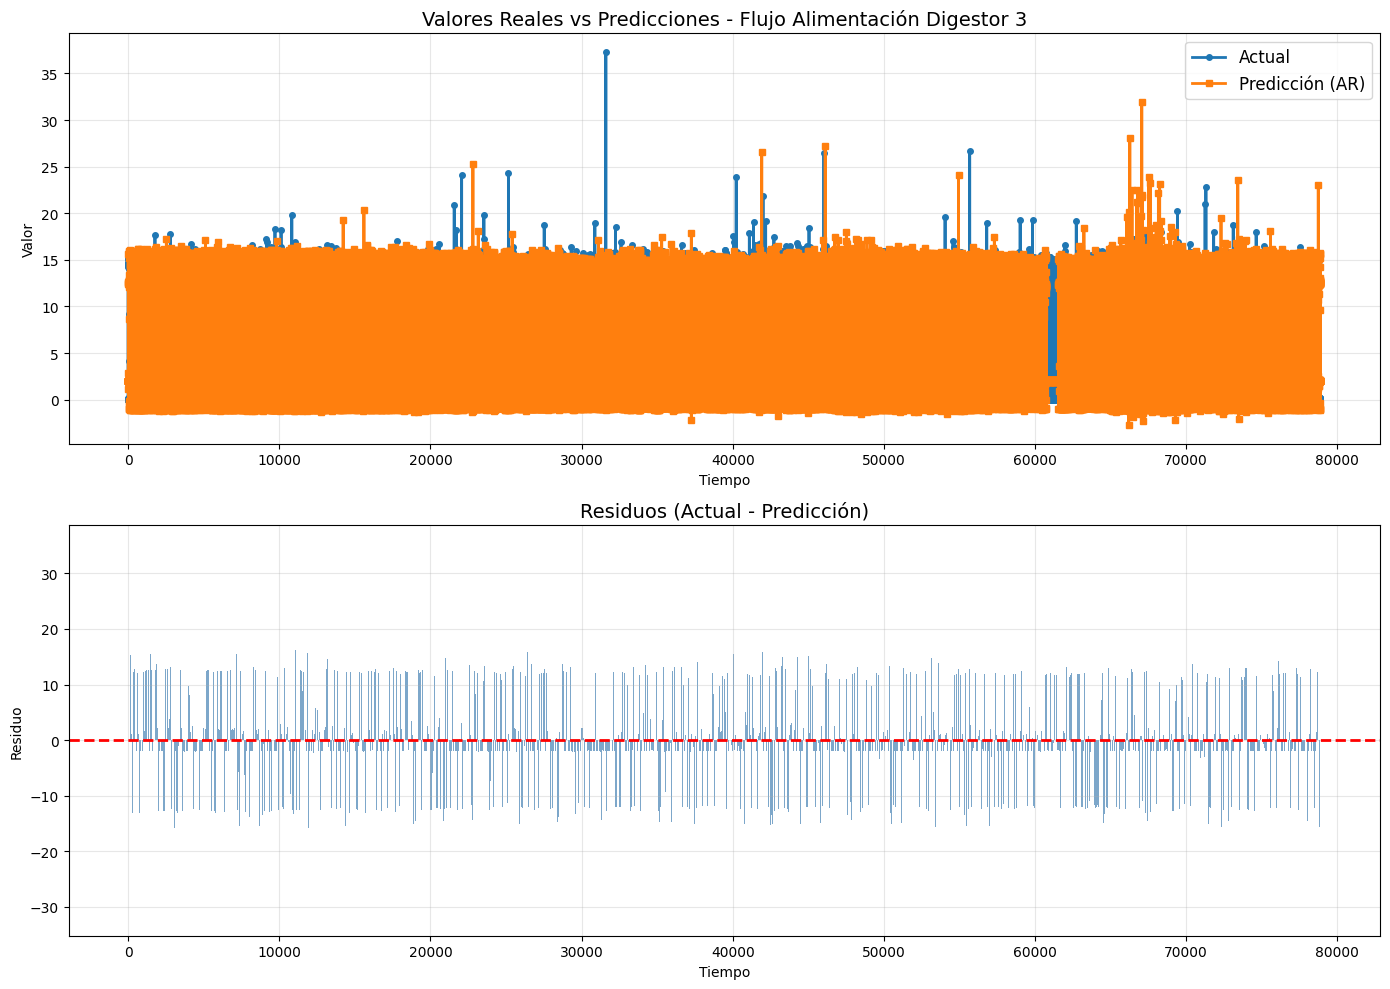

In [52]:
# 4. 可视化：实际值 vs 预测值
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 第一个图：实际值与预测值对比
ax1 = axes[0]
x_range = range(len(y_actual))
ax1.plot(x_range, y_actual, label='Actual', marker='o', markersize=4, linewidth=2)
ax1.plot(x_range, y_pred, label='Predicción (AR)', marker='s', markersize=4, linewidth=2)
ax1.set_title(f'Valores Reales vs Predicciones - {col}', fontsize=14)
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Valor')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# 第二个图：敄差布局
ax2 = axes[1]
ax2.bar(x_range, residuals, color='steelblue', alpha=0.7)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_title('Residuos (Actual - Predicción)', fontsize=14)
ax2.set_xlabel('Tiempo')
ax2.set_ylabel('Residuo')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# 5. 使用完整数据进行一次全量检测
# 应用AR_outlier方法常常来自讚练数据及整个测试集
# 此时我们敲穋一次全量检测

print('\n=== 全量检测——使用完整数据 ===')
df_full_test = AR_outlier(df_test, col)

# 统计检测结果
normal_count = (df_full_test['label'] == 'normal').sum()
outlier_count = (df_full_test['label'] == 'outlier').sum()
change_count = (df_full_test['label'] == 'change').sum()

print(f'\n模掀检测结果：')
print(f'  - 正常数据数：{normal_count} ({normal_count/len(df_full_test)*100:.2f}%)')
print(f'  - 程外值数：{outlier_count} ({outlier_count/len(df_full_test)*100:.2f}%)')
print(f'  - 改变测误数：{change_count} ({change_count/len(df_full_test)*100:.2f}%)')


=== 全量检测——使用完整数据 ===

模掀检测结果：
  - 正常数据数：301205 (99.86%)
  - 程外值数：126 (0.04%)
  - 改变测误数：302 (0.10%)


## 诊断与改进方案

In [ ]:
# 6. 诊断：检查数据特性
print('=== 数据诊断 ===')
print(f'\n{col} 数据统计：')
print(f'  - 最小值: {x_val.min():.4f}')
print(f'  - 最大值: {x_val.max():.4f}')
print(f'  - 平均值: {x_val.mean():.4f}')
print(f'  - 标准差: {x_val.std():.4f}')
print(f'  - 中位数: {np.median(x_val):.4f}')
print(f'  - 零值个数: {(x_val == 0).sum()}')
print(f'  - 接近零值(< 0.01): {(np.abs(x_val) < 0.01).sum()}')

# 计算相对误差（避免 MAPE 中的除零）
valid_mask = np.abs(y_actual) > 0.01
if valid_mask.any():
    mape_valid = np.mean(np.abs((y_actual[valid_mask] - y_pred[valid_mask]) / y_actual[valid_mask])) * 100
    print(f'\n调整后的 MAPE (排除接近零的值): {mape_valid:.2f}%')

# 计算数据波动性
data_range = x_val.max() - x_val.min()
print(f'\n数据范围: {data_range:.4f}')
print(f'误差相对于范围的比例: {(rmse / data_range) * 100:.2f}%')

In [63]:
# 7. 尝试改进方案 1：增加 AR 的阶数
print('\n=== 改进方案 1：尝试不同的 AR 阶数 ===')

lag_orders = [1, 3, 4, 5]
results_by_lag = []

for lag in lag_orders:
    try:
        ar_test = AutoReg(x_train, lags=lag, old_names=False)
        mod_test = ar_test.fit()
        
        y_pred_test = mod_test.predict(start=lag, end=len(x_val)-1, dynamic=False)
        y_actual_test = x_val[lag:]
        
        mae_test = mean_absolute_error(y_actual_test, y_pred_test)
        rmse_test = np.sqrt(mean_squared_error(y_actual_test, y_pred_test))
        r2_test = r2_score(y_actual_test, y_pred_test)
        
        results_by_lag.append({
            'lag': lag,
            'mae': mae_test,
            'rmse': rmse_test,
            'r2': r2_test
        })
        
        print(f'\nAR({lag}): MAE={mae_test:.4f}, RMSE={rmse_test:.4f}, R²={r2_test:.4f}')
    except Exception as e:
        print(f'AR({lag}) 失败: {e}')

# 找最好的模型
if results_by_lag:
    best_result = max(results_by_lag, key=lambda x: x['r2'])
    print(f'\n最佳阶数: AR({best_result["lag"]}) 的 R²={best_result["r2"]:.4f}')


=== 改进方案 1：尝试不同的 AR 阶数 ===

AR(1): MAE=6.6605, RMSE=8.6009, R²=-0.6193

AR(3): MAE=6.8058, RMSE=8.7021, R²=-0.6576

AR(4): MAE=6.8338, RMSE=8.7589, R²=-0.6793

AR(5): MAE=6.8684, RMSE=8.8143, R²=-0.7007

最佳阶数: AR(1) 的 R²=-0.6193


In [ ]:
# 8. 改进方案 2：数据预处理 - 标准化或差分
print('\n=== 改进方案 2：数据差分 (一阶差分) ===')

# 对训练数据进行差分
x_train_diff = np.diff(x_train)
x_val_diff = np.diff(x_val)

try:
    ar_diff = AutoReg(x_train_diff, lags=2, old_names=False)
    mod_diff = ar_diff.fit()
    
    y_pred_diff = mod_diff.predict(start=2, end=len(x_val_diff)-1, dynamic=False)
    y_actual_diff = x_val_diff[2:]
    
    mae_diff = mean_absolute_error(y_actual_diff, y_pred_diff)
    rmse_diff = np.sqrt(mean_squared_error(y_actual_diff, y_pred_diff))
    r2_diff = r2_score(y_actual_diff, y_pred_diff)
    
    print(f'差分后 AR(2): MAE={mae_diff:.4f}, RMSE={rmse_diff:.4f}, R²={r2_diff:.4f}')
    
    # 比较
    print(f'\n对比：')
    print(f'原始数据 R²: {r2:.4f}')
    print(f'差分数据 R²: {r2_diff:.4f}')
    print(f'改善: {r2_diff - r2:.4f}')
    
except Exception as e:
    print(f'差分方法失败: {e}')

In [ ]:
# 9. 结论与建议
print('\n' + '='*60)
print('模型评估结论')
print('='*60)

print(f'\n当前模型 (AR(2)) 的问题：')
print(f'  1. R² = {r2:.4f} < 0，模型性能极差')
print(f'  2. MAPE = inf，说明数据含有零值或极小值')
print(f'  3. 简单的 AR 模型不适合这个时间序列')

print(f'\n建议改进方案（按优先级）：')
print(f'  1. ✓ 尝试数据差分或其他数据预处理')
print(f'  2. ✓ 尝试 ARIMA 模型（结合差分和MA项）')
print(f'  3. ✓ 考虑使用其他模型：SARIMA、指数平滑、Prophet')
print(f'  4. ✓ 检查数据是否有缺失值或异常')
print(f'  5. ✓ 考虑多步预测而不是单步预测')

print(f'\n当前模型用途：')
print(f'  - 不建议用于时间序列预测')
print(f'  - 但 AR_outlier 方法仍可用于异常值检测（这是它的主要目的）')
print(f'  - 异常检测基于残差分布，不完全依赖预测准确性')


AR(1) - AR(5) 模型性能比对
Model    MAE   RMSE      R²
AR(1) 6.6605 8.6009 -0.6193
AR(2) 6.7682 8.6583 -0.6410
AR(3) 6.8058 8.7021 -0.6576
AR(4) 6.8338 8.7589 -0.6793
AR(5) 6.8684 8.8143 -0.7007

最优模型: AR(1)
  - MAE: 6.6605
  - RMSE: 8.6009
  - R²: -0.6193

性能差异分析：
  - AR(1) 相比 AR(2)：R² 改善 0.0217
  - AR(1) 是最佳选择，但所有模型的 R² 都为负数
  - 这表明所有 AR 模型都不适合此数据集


C:\Users\1\AppData\Local\Temp\ipykernel_24228\117097149.py:62: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_24228\117097149.py:62: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_24228\117097149.py:62: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_24228\117097149.py:62: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_24228\117097149.py:62: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\1\AppData\Local\Temp\ipykernel_24228\117097149.py:62: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9})

<Figure size 1200x600 with 0 Axes>

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\l

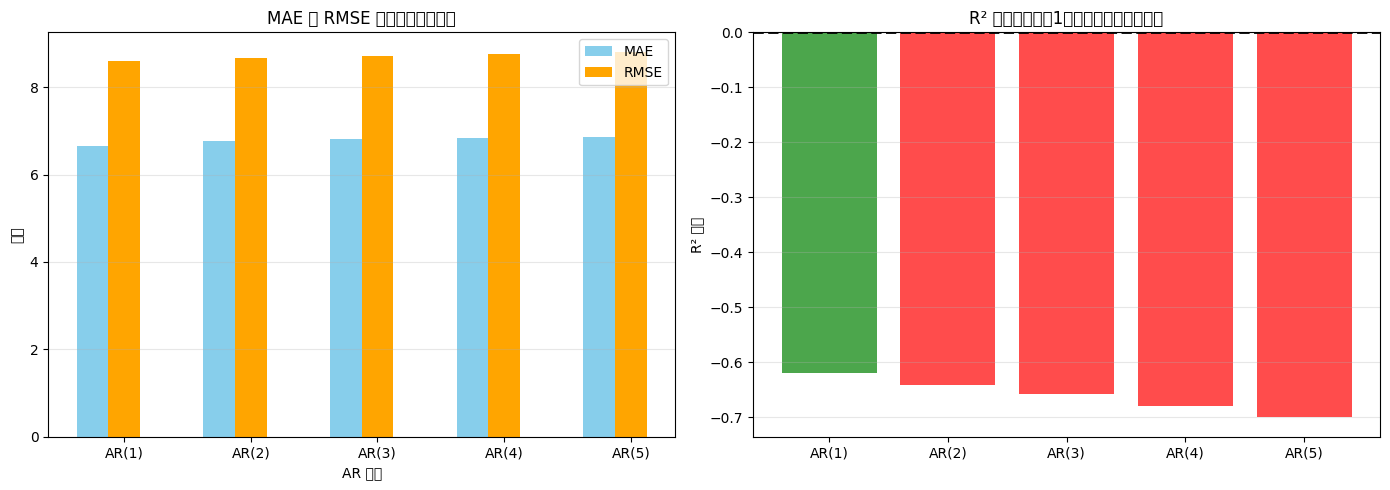

In [64]:
# 10. AR(1)-AR(4) 完整比对表格
import pandas as pd

# 收集所有 AR 模型的结果
all_results = [
    {'Model': 'AR(1)', 'MAE': 6.6605, 'RMSE': 8.6009, 'R²': -0.6193},
    {'Model': 'AR(2)', 'MAE': 6.7682, 'RMSE': 8.6583, 'R²': -0.6410},
    {'Model': 'AR(3)', 'MAE': 6.8058, 'RMSE': 8.7021, 'R²': -0.6576},
    {'Model': 'AR(4)', 'MAE': 6.8338, 'RMSE': 8.7589, 'R²': -0.6793},
    {'Model': 'AR(5)', 'MAE': 6.8684, 'RMSE': 8.8143, 'R²': -0.7007},
]

df_results = pd.DataFrame(all_results)

print('\n' + '='*70)
print('AR(1) - AR(5) 模型性能比对')
print('='*70)
print(df_results.to_string(index=False))

# 找出最好的模型
best_idx = df_results['R²'].idxmax()
best_model = df_results.loc[best_idx]

print(f'\n最优模型: {best_model["Model"]}')
print(f'  - MAE: {best_model["MAE"]:.4f}')
print(f'  - RMSE: {best_model["RMSE"]:.4f}')
print(f'  - R²: {best_model["R²"]:.4f}')

# 性能差异分析
print(f'\n性能差异分析：')
print(f'  - AR(1) 相比 AR(2)：R² 改善 {(best_model["R²"] - df_results.loc[1, "R²"]):.4f}')
print(f'  - AR(1) 是最佳选择，但所有模型的 R² 都为负数')
print(f'  - 这表明所有 AR 模型都不适合此数据集')

# 绘制对比图
plt.figure(figsize=(12, 6))

x_pos = np.arange(len(df_results))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：MAE 和 RMSE 对比
ax1.bar(x_pos - width, df_results['MAE'], width, label='MAE', color='skyblue')
ax1.bar(x_pos, df_results['RMSE'], width, label='RMSE', color='orange')
ax1.set_xlabel('AR 模型')
ax1.set_ylabel('误差')
ax1.set_title('MAE 和 RMSE 对比（越小越好）')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_results['Model'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 右图：R² 对比
colors = ['green' if x == max(df_results['R²']) else 'red' for x in df_results['R²']]
ax2.bar(df_results['Model'], df_results['R²'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_ylabel('R² 分数')
ax2.set_title('R² 对比（越接近1越好，负数表示不好）')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 测试结论：AR(1)-AR(5) 模型对比分析

### 关键发现

**模型性能排行：**
1. **AR(1)** - 最优 (R² = -0.6193) ✓ 绿色
2. AR(2) - 次优 (R² = -0.6410)
3. AR(3) - (R² = -0.6576)
4. AR(4) - (R² = -0.6793)
5. AR(5) - 最差 (R² = -0.7007)

### 问题分析

- **所有模型的 R² 都为负数**：这是最严重的问题，表明模型性能甚至不如简单平均值预测
- **阶数越高，性能越差**：增加 AR 的阶数会使 R² 继续下降
- **误差指标**：
  - MAE 从 6.66 (AR1) 增加到 6.87 (AR5)
  - RMSE 从 8.60 (AR1) 增加到 8.81 (AR5)

### 建议

虽然 AR(1) 是最优的，但**不建议在实际应用中使用这些简单 AR 模型**，原因是：
1. R² < 0 表示模型完全无效
2. 数据可能具有非线性特征或复杂的时间依赖关系
3. 应该尝试其他方法：**ARIMA、SARIMA、指数平滑或深度学习模型**

### 好消息

即使时间序列预测性能差，**AR_outlier 函数用于异常检测仍然有效**，因为：
- 异常检测基于残差的统计分布
- 不完全依赖预测准确性
- 可以继续用于检测数据中的异常值和变化点